## <center><font color=navy>Engineering Analytics VI</font></center>
### <center>Trend-Following/Momentum Strategies</center>

###### Adaptado do material de Ali Habibnia (https://github.com/AliHabibnia/Algorithmic_Trading_with_Python/)

# Estratégias Baseadas em Tendência e Momentum

Estratégias de negociação baseadas em tendência e momentum são técnicas de investimento que buscam capitalizar o movimento contínuo de um ativo em uma direção específica. Essas estratégias são frequentemente utilizadas por traders em diversos mercados financeiros, como ações, forex, commodities e outros.

A aplicação bem-sucedida dessas estratégias requer uma análise cuidadosa, gerenciamento de risco e, frequentemente, um bom entendimento do ativo subjacente e das condições de mercado. Muitos traders também utilizam indicadores técnicos, padrões de gráfico e, por vezes, análise fundamentalista em conjunto com essas estratégias para aumentar as chances de sucesso.

### Moving average crossover


A média móvel crossover é considerada o "Hello World" e o primeiro passo quando você deseja se aprofundar em estratégias de negociação algorítmica e negociação quantitativa.

O primeiro tipo de estratégia de crossover é o crossover de preço:

1. Calcule a **SMA** de n dias.
2. **Posição Longa:** Entre na operação quando o preço fechar acima da média móvel. Saia da operação quando o preço fechar abaixo da média móvel.
3. **Posição Curta:** Venda a descoberto quando o preço fechar abaixo da média móvel. Compre para cobrir quando o preço fechar acima da média móvel.

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

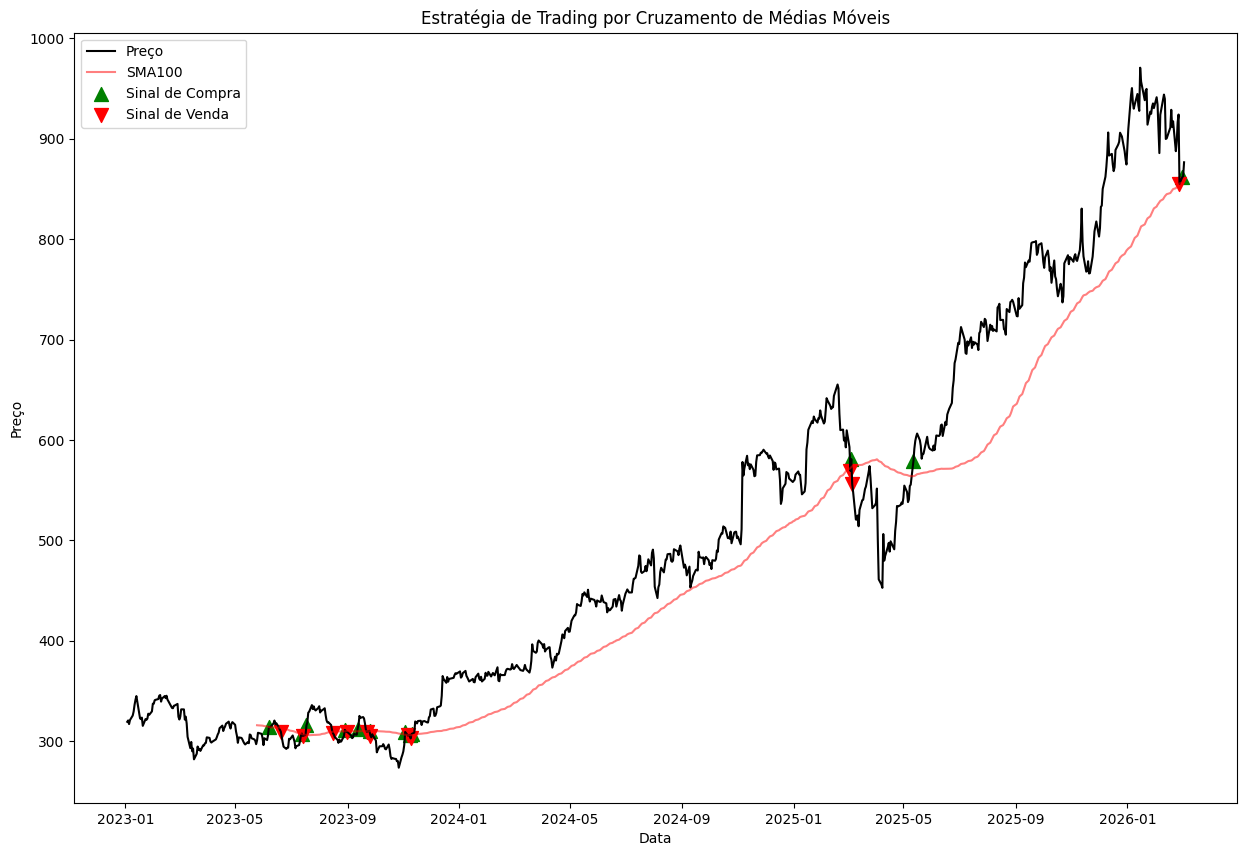

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

# Baixa os dados do Yahoo Finance
df = yf.download('GS', start='2023-01-01', progress=False)
df = df.droplevel(level=1, axis=1)

# Calcula a média móvel simples de 100 dias
df['SMA100'] = df['Close'].rolling(window=100).mean()

# Identifica sinais de compra e venda
df['Signal'] = 0  # Padrão: sem sinal
df.loc[df['Close'] > df['SMA100'], 'Signal'] = 1  # Sinal acima da SMA
df.loc[df['Close'] < df['SMA100'], 'Signal'] = -1  # Sinal abaixo da SMA
df['Position'] = df['Signal'] - df['Signal'].shift(1)  # Determina onde a posição muda

# Sinais de compra ocorrem quando a Posição é 2 (cruzando de -1 para 1) e sinais de venda quando a Posição é -2 (cruzando de 1 para -1)
buy_signals = df[df['Position'] == 2]
sell_signals = df[df['Position'] == -2]

# Plota os dados
plt.figure(figsize=(15, 10))
plt.plot(df['Close'], label='Preço', color='black', alpha=1)
plt.plot(df['SMA100'], label='SMA100', color='red', alpha=0.5)
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Sinal de Compra', alpha=1, s=100)
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sinal de Venda', alpha=1, s=100)
plt.title('Estratégia de Trading por Cruzamento de Médias Móveis')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.show()


### Versão incapsulada

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.graph_objects as go

def cruzamento_media_movel(simbolo, periodo_media_movel, start_date='2020-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    # Baixa os dados do Yahoo Finance
    df = yf.download(simbolo, start=start_date, end=end_date, progress=False)
    df = df.droplevel(level=1, axis=1)
    
    # Calcula a Média Móvel Simples (SMA)
    df['SMA'] = df['Close'].rolling(window=periodo_media_movel).mean()

    # Identifica sinais de compra e venda
    df['Signal'] = 0  # Padrão: sem sinal
    df.loc[df['Close'] > df['SMA'], 'Signal'] = 1  # Sinal de compra: preço acima da SMA
    df.loc[df['Close'] < df['SMA'], 'Signal'] = -1  # Sinal de venda: preço abaixo da SMA
    df['Position'] = df['Signal'] - df['Signal'].shift(1)  # Determina onde a posição muda

    # Sinais de compra ocorrem quando Position é 2 e sinais de venda quando Position é -2
    sinais_compra = df[df['Position'] == 2]
    sinais_venda = df[df['Position'] == -2]

    # Plota os dados utilizando Plotly
    fig = go.Figure()
    # Plota os preços de fechamento
    fig.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Preço', line=dict(color='black')))
    # Plota a média móvel
    fig.add_trace(go.Scatter(x=df.index, y=df['SMA'], mode='lines', name=f'SMA{periodo_media_movel}', line=dict(color='red', width=0.5)))
    # Adiciona os sinais de compra
    fig.add_trace(go.Scatter(x=sinais_compra.index, y=sinais_compra['Close'], mode='markers', name='Sinal de Compra', marker=dict(color='green', size=10, symbol='triangle-up')))
    # Adiciona os sinais de venda
    fig.add_trace(go.Scatter(x=sinais_venda.index, y=sinais_venda['Close'], mode='markers', name='Sinal de Venda', marker=dict(color='red', size=10, symbol='triangle-down')))
    # Personaliza o layout do gráfico
    fig.update_layout(
        title=f'Estratégia de Cruzamento de Médias Móveis para {simbolo}',
        xaxis_title='Data',
        yaxis_title='Preço',
    )
    # Exibe o gráfico
    fig.show()

In [4]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [5]:
cruzamento_media_movel('GS', 100)

### Uma abordagem "ingênua" de backtesting

O código a seguir realizará o backtest da estratégia de negociação de média móvel crossover para vários períodos de média móvel (de 2 a 100) para um determinado símbolo de ação, dentro de um intervalo de datas especificado. Ele classificará os períodos de média móvel com base no lucro ou prejuízo gerado pela estratégia.

In [6]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def backtest_cruzamento_media_movel(simbolo, start_date='2020-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    # Baixa os dados do Yahoo Finance
    df = yf.download(simbolo, start=start_date, end=end_date, progress=False)
    df = df.droplevel(level=1, axis=1)
    
    resultados = []
    
    for periodo_media_movel in range(2, 101):
        # Calcula a Média Móvel Simples (SMA)
        df['SMA'] = df['Close'].rolling(window=periodo_media_movel).mean()

        # Identifica os sinais de compra e venda
        df['Signal'] = 0  # Padrão: sem sinal
        df.loc[df['Close'] > df['SMA'], 'Signal'] = 1  # Sinal de compra: preço acima da SMA
        df.loc[df['Close'] < df['SMA'], 'Signal'] = -1  # Sinal de venda: preço abaixo da SMA
        df['Position'] = df['Signal'] - df['Signal'].shift(1)  # Determina onde a posição muda

        # Calcula os retornos diários
        df['Daily_Return'] = df['Close'].pct_change() * df['Signal'].shift(1)

        # Calcula os retornos cumulativos
        retorno_cumulativo = (df['Daily_Return'] + 1).prod() - 1

        # Armazena os resultados no formato de porcentagem
        resultados.append((periodo_media_movel, retorno_cumulativo * 100))
    
    # Converte os resultados em um DataFrame
    resultados_df = pd.DataFrame(resultados, columns=['Período da Média Móvel', 'Lucro/Prejuízo (%)'])
    
    # Ordena os resultados pelo retorno cumulativo e reinicia o índice
    resultados_df.sort_values(by='Lucro/Prejuízo (%)', ascending=False, inplace=True)
    resultados_df.reset_index(drop=True, inplace=True)
    
    return resultados_df

<AxesSubplot: xlabel='Período da Média Móvel'>

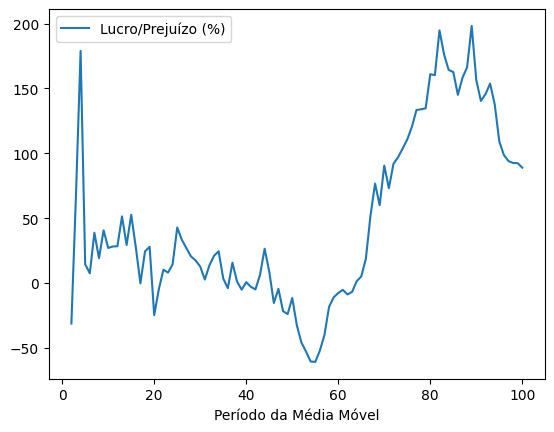

In [7]:
backtest_cruzamento_media_movel('GS').sort_values('Período da Média Móvel').set_index('Período da Média Móvel').plot()

In [8]:
pd.set_option('display.max_rows', 100)
#pd.reset_option('display.max_rows')

backtest_cruzamento_media_movel('GS')

,Período da Média Móvel,Lucro/Prejuízo (%)
0,89,198.190474
1,82,194.750342
2,4,178.901455
3,83,176.162788
4,88,166.305269
5,84,164.231368
6,85,162.644545
7,80,160.974272
8,81,160.252123
9,87,158.177066


Os resultados são baseados em dados históricos e são altamente sensíveis ao período de amostragem. Não há garantia de que o melhor período de média móvel do passado produzirá o mesmo desempenho no futuro. Testes de robustez e uma validação mais abrangente são essenciais antes de implementar qualquer estratégia de negociação baseada nesses resultados. Vamos comparar dois períodos diferentes:

In [9]:
# Exemplo de uso:
periodo1 = backtest_cruzamento_media_movel('GS', '2021-01-01', '2022-01-01')
periodo2 = backtest_cruzamento_media_movel('GS', '2022-01-01', '2023-01-01')

# Renomeia as colunas
periodo1.columns = ['Média_Móvel_1', 'Lucro/Prejuízo_1 (%)']
periodo2.columns = ['Média_Móvel_2', 'Lucro/Prejuízo_2 (%)']

# Converte lucro/prejuízo para formato percentual
periodo1['Lucro/Prejuízo_1 (%)'] = periodo1['Lucro/Prejuízo_1 (%)'].apply(lambda x: f"{x:.2f}%")
periodo2['Lucro/Prejuízo_2 (%)'] = periodo2['Lucro/Prejuízo_2 (%)'].apply(lambda x: f"{x:.2f}%")

# Concatena os resultados de ambos os períodos
resultados_finais = pd.concat([periodo1, periodo2], axis=1)

# Imprime os resultados finais em formato de tabela
print(resultados_finais)

    Média_Móvel_1 Lucro/Prejuízo_1 (%)  Média_Móvel_2 Lucro/Prejuízo_2 (%)
0               3               84.78%              8              126.01%
1               4               60.62%              9              104.52%
2               2               45.82%              7              103.91%
3              12               10.07%              6               85.71%
4              24                8.77%              4               75.20%
5              25                8.26%             10               58.58%
6               5                7.15%              5               43.81%
7              11                6.19%             11               31.42%
8              19                5.82%             15               20.04%
9              20                5.79%             12               19.77%
10             22                5.60%              2               19.30%
11             21                4.89%              3               18.26%
12             14        

### Dual Moving average crossover


Esta estratégia de negociação pode ser simplificada nestes quatro passos:
1. Calcule a **SMA** de 5 dias (SMA com período de lookback mais curto).
2. Calcule a **SMA** de 20 dias (SMA com período de lookback mais longo).
3. **Posição Longa:** Entre na operação quando a SMA de 5 dias (período de lookback mais curto) for maior ou igual à SMA de 20 dias (período de lookback mais longo).
4. **Posição Curta:** Venda a descoberto quando a SMA de 5 dias (período de lookback mais curto) for menor que a SMA de 20 dias (período de lookback mais longo).






In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def cruzamento_duas_medias_moveis(simbolo, periodo_media_curta, periodo_media_longa, start_date='2021-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    # Baixa os dados do Yahoo Finance
    df = yf.download(simbolo, start=start_date, end=end_date, progress=False)
    df = df.droplevel(level=1, axis=1)

    # Calcula as Médias Móveis Curta e Longa
    df['Short_SMA'] = df['Close'].rolling(window=periodo_media_curta).mean()
    df['Long_SMA'] = df['Close'].rolling(window=periodo_media_longa).mean()

    # Identifica os sinais de compra e venda
    df['Signal'] = 0  # Padrão: sem sinal
    df.loc[df['Short_SMA'] > df['Long_SMA'], 'Signal'] = 1   # Sinal de compra: média curta acima da média longa
    df.loc[df['Short_SMA'] < df['Long_SMA'], 'Signal'] = -1  # Sinal de venda: média curta abaixo da média longa
    df['Position'] = df['Signal'] - df['Signal'].shift(1)  # Determina onde ocorre a mudança de posição

    # Sinais de compra ocorrem quando Position é 2 e sinais de venda quando Position é -2
    sinais_compra = df[df['Position'] == 2]
    sinais_venda = df[df['Position'] == -2]

    # Plota os dados
    plt.figure(figsize=(15, 10))
    plt.plot(df['Close'], label='Preço', color='black', alpha=1)
    plt.plot(df['Short_SMA'], label=f'Média Curta ({periodo_media_curta})', color='blue', alpha=0.5)
    plt.plot(df['Long_SMA'], label=f'Média Longa ({periodo_media_longa})', color='red', alpha=0.5)
    # Marca os sinais de compra usando a média curta para posicionamento dos marcadores
    plt.scatter(sinais_compra.index, sinais_compra['Short_SMA'], marker='^', color='green', label='Sinal de Compra', alpha=1, s=100)
    # Marca os sinais de venda usando a média curta para posicionamento dos marcadores
    plt.scatter(sinais_venda.index, sinais_venda['Short_SMA'], marker='v', color='red', label='Sinal de Venda', alpha=1, s=100)
    plt.title(f'Estratégia de Cruzamento de Médias Móveis Duplas para {simbolo}')
    plt.xlabel('Data')
    plt.ylabel('Preço')
    plt.legend()
    plt.show()

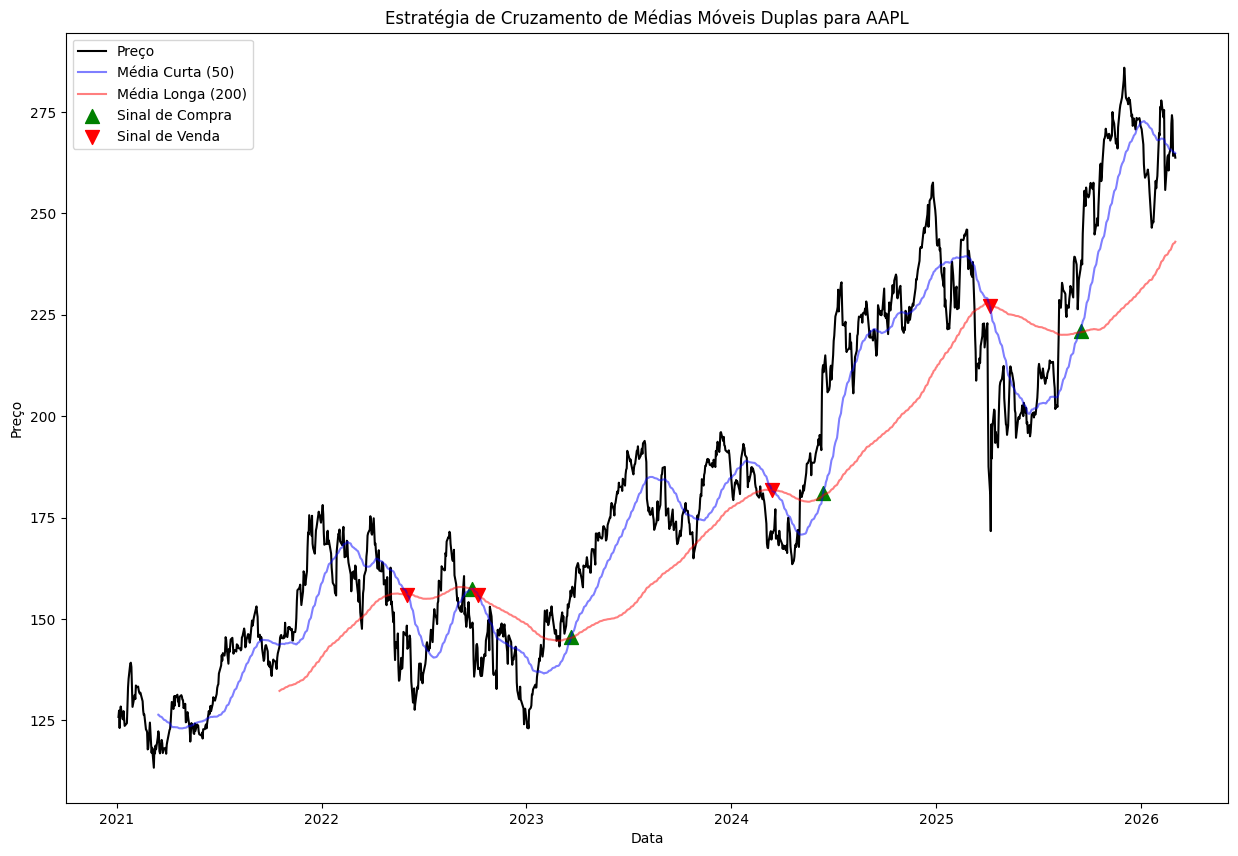

In [11]:
cruzamento_duas_medias_moveis('AAPL', 50, 200)

# Estratégias de Reversão à Média

Estratégias de negociação de reversão à média são estratégias de investimento que se aproveitam do desvio dos preços dos ativos e da subsequente volta ao preço médio ao longo do tempo. A ideia é que os ativos, sejam eles ações, moedas, commodities ou outros instrumentos financeiros, tendem a flutuar em torno de um preço médio de longo prazo. Quando os preços se desviam significativamente de suas médias históricas, um trader que utiliza a reversão à média assume posições antecipando o retorno ao preço médio. A seguir, alguns aspectos comuns das estratégias de reversão à média:

### Tipos de Estratégias de Reversão à Média

1. **Reversão à Média de Ativo Único**:  
   Nesta estratégia, os traders analisam o preço médio histórico de um ativo. Quando o preço do ativo se desvia significativamente desse valor médio, eles compram se o preço estiver baixo e vendem se estiver alto, antecipando o retorno à média.

2. **Negociação de Pares**:  
   Essa estratégia envolve assumir uma posição longa em um ativo e uma posição curta em outro ativo relacionado quando os seus preços divergem de uma relação média histórica. A ideia é que os preços relativos dos dois ativos retornarão à média ao longo do tempo.

3. **Reversão à Média Setorial**:  
   Semelhante à negociação de pares, mas envolve múltiplos ativos de um setor específico. Por exemplo, se as ações de tecnologia se desviarem de sua avaliação média em comparação com o mercado mais amplo, uma estratégia de reversão à média setorial poderia envolver assumir posições longas e curtas adequadas entre as ações de tecnologia e o índice do mercado mais amplo.

4. **Reversão à Média Cambial**:  
   Esta estratégia é frequentemente utilizada no mercado Forex. Os traders identificam pares de moedas que se desviaram de suas taxas de câmbio médias históricas e assumem posições que antecipam um retorno à média.

5. **Estratégias Baseadas em Opções**:  
   Utilizando opções, os traders também podem criar estratégias de reversão à média mais complexas, que podem oferecer proteção contra quedas ou alavancagem.

### Riscos e Limitações

1. **Mercados que Não Revertam à Média**:  
   Nem todos os mercados ou ativos se comportam de forma reversão à média. Em mercados fortemente direcionais, estratégias de reversão à média podem falhar.

2. **Mudanças Fundamentais**:  
   Se os fundamentos de um ativo mudarem, a média histórica pode não ser mais relevante.

3. **Custos e Slippage**:  
   Os custos de negociação podem reduzir os lucros, especialmente em estratégias de reversão à média de alta frequência.

4. **Estresse Psicológico**:  
   Essas estratégias frequentemente envolvem assumir posições contrárias à tendência predominante do mercado, o que pode ser estressante para os traders.

5. **Natureza Estatística**:  
   As estratégias são baseadas em probabilidades, portanto, não há garantias.

Estratégias de reversão à média podem ser lucrativas, mas vêm acompanhadas de seus próprios riscos e limitações. Antes de implementar uma estratégia desse tipo, é essencial realizar um backtesting completo e uma avaliação de risco.

## Reversão à Média de Ações Individuais

A reversão à média no contexto do preço de uma ação implica que períodos em que o preço está muito abaixo da média são seguidos por períodos de alta, e vice-versa. Podemos aproveitar essa situação comprando a ação (posição longa) quando o preço estiver abaixo do esperado, e vendendo a descoberto (posição curta) quando o preço estiver acima do esperado. Podemos plotar o preço de uma ação juntamente com a média dos preços até cada dia para verificar se o preço reverte para a média. Note que, como estamos calculando a média móvel, "reverter para a média" não significa necessariamente atingir os mesmos níveis altos ou baixos que ocorreram anteriormente.

Para negociar utilizando essa estratégia, precisamos quantificar o que significa o preço estar acima ou abaixo do esperado. É útil calcular o z-score do preço em cada dia, que indica quantos desvios padrão um valor está afastado da média:

$$
z = \frac{x - \mu}{\sigma}
$$

onde $x$ é o valor, $\mu$ é a média do conjunto de dados e $\sigma$ é o seu desvio padrão. Assim, um preço com um z-score $> 1$ está mais de um desvio padrão acima da média, e venderemos a descoberto quando isso acontecer. Se o preço em um dia tiver um z-score $< -1$, compraremos para assumir posição longa. Se o preço estiver dentro de meio desvio padrão da média, encerraremos todas as posições.

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

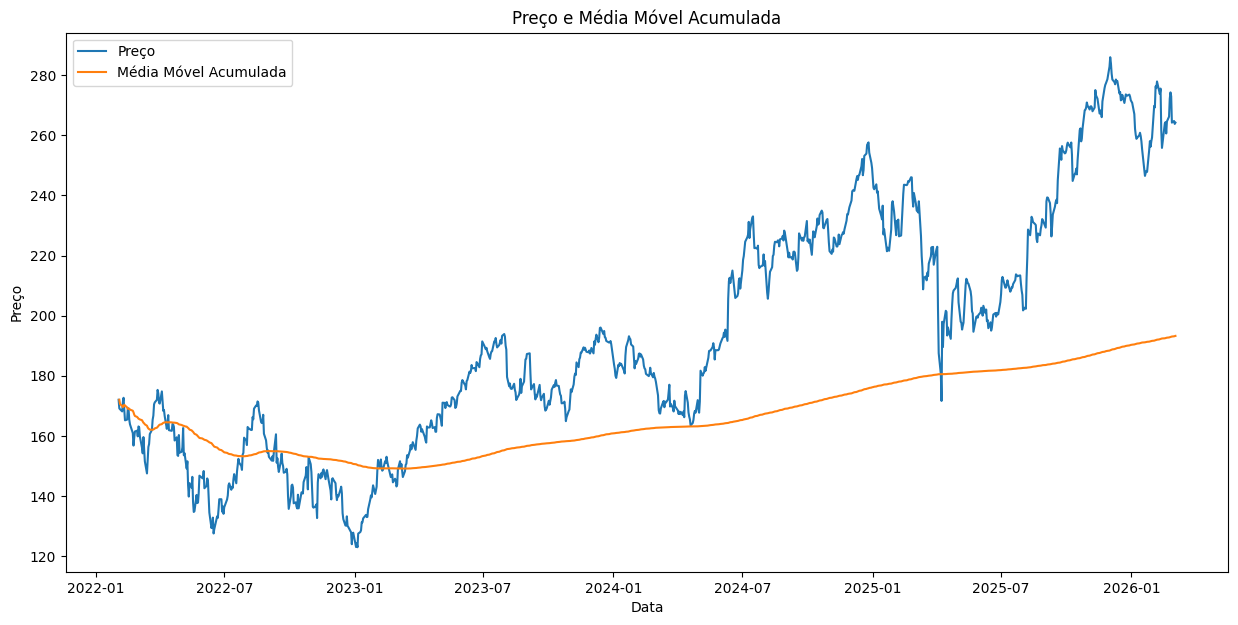

In [13]:
# Baixa os dados da ação AAPL a partir de 2022-02-02
df = yf.download('AAPL', start='2022-02-02', progress=False)
df = df.droplevel(level=1, axis=1)

# Calcula a média móvel acumulada do preço
df['media_acumulada'] = [df['Close'][:i].mean() for i in range(len(df))]

# Plota o preço e a média móvel acumulada
plt.figure(figsize=(15, 7))
plt.plot(df['Close'], label='Preço')
plt.plot(df['media_acumulada'], label='Média Móvel Acumulada')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.title('Preço e Média Móvel Acumulada')
plt.legend()
plt.show()

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

def backtest_reversao_media_zscore(simbolo, start_date='2020-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    # Baixa os dados do Yahoo Finance e ajusta o DataFrame
    df = yf.download(simbolo, start=start_date, end=end_date, progress=False)
    df = df.droplevel(level=1, axis=1)
    
    resultados = []
    
    # Loop para testar diferentes tamanhos de janela para o cálculo rolante
    for janela in range(2, 101):
        df['rolling_mean'] = df['Close'].rolling(window=janela).mean()
        df['rolling_std'] = df['Close'].rolling(window=janela).std()
        
        # Calcula o zscore com base na média e desvio padrão rolantes
        df['zscore'] = (df['Close'] - df['rolling_mean']) / df['rolling_std']
        df['zscore'] = df['zscore'].fillna(0)  # Evita NaN no início da série
        
        # Gera sinais de operação:
        # zscore > 1: vende a descoberto (short, sinal = -1)
        # zscore < -1: compra (long, sinal = 1)
        # |zscore| < 0.5: liquida a posição (sinal = 0)
        df['Signal'] = np.nan
        df.loc[df['zscore'] > 1, 'Signal'] = -1
        df.loc[df['zscore'] < -1, 'Signal'] = 1
        df.loc[df['zscore'].abs() < 0.5, 'Signal'] = 0
        # Nos dias em que nenhuma condição é atendida, mantém o sinal do dia anterior
        df['Signal'] = df['Signal'].ffill().fillna(0)
        
        # Calcula o retorno diário utilizando o sinal do dia anterior
        df['Daily_Return'] = df['Close'].pct_change() * df['Signal'].shift(1)
        
        # Calcula o retorno acumulado
        retorno_cumulativo = (df['Daily_Return'] + 1).prod() - 1
        
        # Armazena o resultado (tamanho da janela e retorno em %) para esta configuração
        resultados.append((janela, retorno_cumulativo * 100))
    
    # Converte os resultados em DataFrame e ordena pelo retorno acumulado
    resultados_df = pd.DataFrame(resultados, columns=['Janela (Rolling Window)', 'Lucro/Prejuízo (%)'])
    resultados_df.sort_values(by='Lucro/Prejuízo (%)', ascending=False, inplace=True)
    resultados_df.reset_index(drop=True, inplace=True)
    
    return resultados_df

In [15]:
pd.set_option('display.max_rows', 100)
#pd.reset_option('display.max_rows')

backtest_reversao_media_zscore('GS')

,Janela (Rolling Window),Lucro/Prejuízo (%)
0,2,0.000000
1,3,-5.760053
2,40,-23.416734
3,93,-24.009585
4,89,-24.174852
5,39,-28.440157
6,90,-28.599852
7,41,-29.803553
8,88,-30.508777
9,42,-30.646560


## Pairs Trading

### Mas antes, um pouco sobre cointegração...

<img src="matematica.png" alt="alt text" title="Title" width="700" />

# Correlação e Cointegração

## Correlação

A **correlação** é uma medida estatística que quantifica o grau de relação linear entre duas variáveis. Ela indica o quanto e de que forma duas variáveis se movem juntas. O coeficiente de correlação de Pearson, o mais utilizado, varia de $-1$ a $1$:

- **$1$:** Correlação linear positiva perfeita.
- **$-1$:** Correlação linear negativa perfeita.
- **$0$:** Ausência de correlação linear.

A fórmula do coeficiente de correlação de Pearson entre duas variáveis $X$ e $Y$ é:
$$
\rho_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X\, \sigma_Y},
$$
onde:
- $\operatorname{Cov}(X,Y)$ é a covariância entre $X$ e $Y$.
- $\sigma_X$ e $\sigma_Y$ são os desvios padrão de $X$ e $Y$, respectivamente.

## Cointegração

A **cointegração** é um conceito aplicado a séries temporais, especialmente quando estas são não estacionárias (isto é, possuem tendências ou variabilidade que muda com o tempo). Duas ou mais séries temporais não estacionárias são ditas cointegradas se uma combinação linear delas resulta em uma série estacionária. Essa propriedade sugere que, apesar de cada série seguir sua própria tendência, elas compartilham uma relação de equilíbrio de longo prazo.

Formalmente, considere duas séries não estacionárias $X_t$ e $Y_t$. Elas são cointegradas se existir um coeficiente $\beta$ tal que:
$$
Z_t = Y_t - \beta\, X_t
$$
seja estacionária. Esse conceito é testado por métodos como o teste de Engle-Granger ou o teste de Johansen.

## Diferenças entre Correlação e Cointegração

- **Correlação:**
  - Mede a relação linear entre duas variáveis, sem levar em conta a estacionariedade.
  - Pode ser aplicada tanto a dados estacionários quanto não estacionários.
  - Um alto coeficiente de correlação indica que as variáveis se movem juntas, mas não implica necessariamente em uma relação de equilíbrio de longo prazo.

- **Cointegração:**
  - Aplica-se a séries temporais não estacionárias.
  - Indica que, apesar de cada série apresentar comportamentos não estacionários, existe uma combinação linear das séries que é estacionária.
  - Sugere a existência de uma relação de longo prazo que "liga" as séries, mantendo-as unidas mesmo que, individualmente, elas possam divergir temporariamente.

Em resumo, enquanto a correlação foca na relação linear entre duas variáveis em um determinado momento, a cointegração analisa se há uma relação de equilíbrio de longo prazo entre séries temporais não estacionárias.


# Teste de Augmented Dickey-Fuller (ADF)

O teste de Augmented Dickey-Fuller (ADF) é um método estatístico utilizado para verificar se uma série temporal é estacionária ou possui uma raiz unitária (indicativo de não estacionariedade). A seguir, descrevemos passo a passo como o teste ADF é realizado:

## 1. Definição do Objetivo
Determinar se a série possui uma raiz unitária. Em termos simples, queremos saber se as propriedades estatísticas (média, variância) da série mudam ao longo do tempo (não estacionária) ou se permanecem constantes (estacionária).

## 2. Formulação das Hipóteses
- **Hipótese Nula ($H_0$):** A série possui uma raiz unitária (não estacionária).
- **Hipótese Alternativa ($H_1$):** A série é estacionária (não possui raiz unitária).

## 3. Especificação do Modelo de Regressão
O teste ADF se baseia na seguinte regressão:
$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \epsilon_t,
$$
onde:
- $\Delta y_t = y_t - y_{t-1}$ é a primeira diferença da série.
- $\alpha$ é o intercepto.
- $\beta t$ é um termo de tendência (inclusão opcional, dependendo do comportamento da série).
- $y_{t-1}$ é o valor defasado da série.
- $\gamma$ é o coeficiente que será avaliado para testar a presença de raiz unitária.
- $\sum_{i=1}^{p} \delta_i\, \Delta y_{t-i}$ representa os termos de defasagem das diferenças, que ajudam a capturar a autocorrelação dos resíduos.
- $\epsilon_t$ é o termo de erro (ruído branco).

## 4. Escolha do Número de Defasagens ($p$)
É essencial escolher um número adequado de defasagens para corrigir a autocorrelação dos resíduos. O valor de $p$ pode ser determinado utilizando critérios de informação (como AIC ou BIC) ou por meio da inspeção dos resíduos.

## 5. Estimação do Modelo
O modelo é ajustado via regressão para obter o coeficiente $\gamma$ e seu erro padrão. O foco é testar a hipótese de que $\gamma = 0$.

## 6. Interpretação do Coeficiente $\gamma$
- Se $\gamma = 0$, a série possui uma raiz unitária, isto é, ela é não estacionária.
- Se $\gamma$ for estatisticamente menor que zero (ou seja, o valor t for menor que o valor crítico), rejeita-se $H_0$, indicando que a série é estacionária.

## 7. Cálculo da Estatística t e Comparação com Valores Críticos
Após ajustar o modelo, calcula-se a estatística t do coeficiente $\gamma$. Essa estatística é comparada com os valores críticos tabelados (que variam conforme o tamanho da amostra e os termos incluídos no modelo). Se a estatística t for menor que o valor crítico, rejeita-se $H_0$.

## 8. Conclusão do Teste
- **Rejeição de $H_0$:** Se o valor t for significativamente baixo, conclui-se que a série é estacionária.
- **Não rejeição de $H_0$:** Se o valor t não for suficientemente baixo, não há evidências para afirmar que a série é estacionária, indicando que ela possui raiz unitária (não estacionária).

Esse processo é fundamental para a análise de séries temporais, permitindo validar a estacionariedade dos dados antes de aplicar outros modelos ou estratégias de previsão.


# Teste de Engle-Granger (CADF)

O teste de Engle-Granger, também conhecido como CADF (Cointegrating Augmented Dickey-Fuller), é um procedimento em duas etapas utilizado para verificar a cointegração entre duas séries temporais não estacionárias. Ele verifica se existe uma relação de equilíbrio de longo prazo entre as séries. A seguir, descrevemos as etapas do teste:

## 1. Regressão de Cointegração

Primeiro, estima-se uma relação de equilíbrio de longo prazo entre as duas séries. Suponha que temos duas séries não estacionárias, $X_t$ e $Y_t$. Realiza-se a regressão:

$$
Y_t = \alpha + \beta\, X_t + u_t,
$$

onde:
- $ \alpha $ é o intercepto,
- $ \beta $ é o coeficiente de inclinação,
- $ u_t $ representa os resíduos da regressão (que refletem os desvios da relação de equilíbrio).

## 2. Teste de Estacionariedade dos Resíduos (CADF)

Em seguida, verifica-se se os resíduos $u_t$ são estacionários. Para isso, aplica-se o teste de Dickey-Fuller aumentado (ADF) aos resíduos, utilizando a seguinte equação:

$$
\Delta u_t = \gamma\, u_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta u_{t-i} + \epsilon_t,
$$

onde:
- $ \Delta u_t = u_t - u_{t-1} $ é a primeira diferença dos resíduos,
- $ \gamma $ é o coeficiente cujo valor é testado (a hipótese nula é de que $ \gamma = 0 $, ou seja, presença de raiz unitária),
- $ p $ é o número de defasagens incluídas para capturar a autocorrelação dos resíduos,
- $ \epsilon_t $ é o termo de erro.

Se o teste rejeitar a hipótese nula (indicando que $ \gamma $ é significativamente menor que zero), conclui-se que os resíduos $u_t$ são estacionários.

## Conclusão

- **Resíduos Estacionários:** Se os resíduos $u_t$ forem estacionários, isso indica que as séries $X_t$ e $Y_t$ são cointegradas, ou seja, apesar de serem não estacionárias individualmente, elas mantêm uma relação de equilíbrio de longo prazo.
- **Resíduos Não Estacionários:** Se os resíduos não forem estacionários, não há evidência de cointegração entre as séries.

Este teste é amplamente utilizado em econometria e análise de séries temporais para identificar relações de longo prazo entre variáveis, o que é fundamental para modelagens financeiras, macroeconômicas, entre outras.


### Voltando ao mundo normal

 Em negociação de pares, a quantidade que estamos examinando é a distância entre dois ativos, a qual esperamos que retorne à sua média. Para que essa suposição seja razoável, é necessário que os dois ativos sejam estatisticamente cointegrados. Na prática, duas empresas cujos produtos são substitutos uma da outra costumam ser cointegradas. Ou seja, elas geralmente se movem juntas devido a variações no mercado e em seu setor específico, apresentando pouca variação relativa entre si.

Como incorporamos a previsão sobre a diferença entre eles em nosso portfólio? Suponha que estamos analisando dois ativos, X e Y. Nesse caso, assumimos posição longa em X e curta em Y quando eles estão mais próximos do que o esperado, e posição curta em X e longa em Y quando estão mais distantes. Dessa forma, permanecemos neutros em relação ao mercado, ao setor e a outras mudanças que fazem X e Y se moverem juntos, enquanto lucramos com a reversão da diferença para a média. Podemos quantificar "mais próximos do que o esperado" como uma diferença com z-score menor que -1, e "mais distantes do que o esperado" como um z-score maior que 1. Isso é mais fácil de visualizar se o preço de X for superior ao de Y, mas o resultado final é o mesmo em ambos os casos.

Utilizando a função coint do statsmodels, vamos verificar se os preços das ações da Coca-Cola e da Pepsi são cointegrados.

In [16]:
from statsmodels.tsa.stattools import coint

# Carrega os preços de Coca e Pepsi
data = yf.download(['KO', 'PEP'], start= '2020-01-01', end='2024-01-01', progress=False)
X = data['Close']['KO']
Y = data['Close']['PEP']
# Calcula o p-valor para o teste de cointegração
coint_t, pvalue, crit_value = coint(X,Y)
print (coint_t, pvalue, crit_value)

-3.1736768782992155 0.07444131882984735 [-3.90737061 -3.34221646 -3.04867279]


A cointegração, de forma bem simplificada, é uma forma "diferente" de correlação. Se duas séries são cointegradas, a razão entre elas varia em torno de uma média. Para que a negociação de pares funcione entre duas séries temporais, o valor esperado dessa razão ao longo do tempo deve convergir para a média, ou seja, elas devem ser cointegradas.

A hipótese nula é que não há cointegração, enquanto a hipótese alternativa é que existe uma relação de cointegração. Se o valor-p for pequeno, abaixo de um nível crítico, então podemos rejeitar a hipótese de que não existe relação de cointegração.

O valor-p é baixo, portanto, as duas séries são cointegradas. Em seguida, precisamos encontrar a média da diferença. Calcularemos a média móvel cumulativa — isto é, a média de todos os valores até cada dia — como se estivéssemos analisando os dados diariamente, sem conhecimento do futuro.

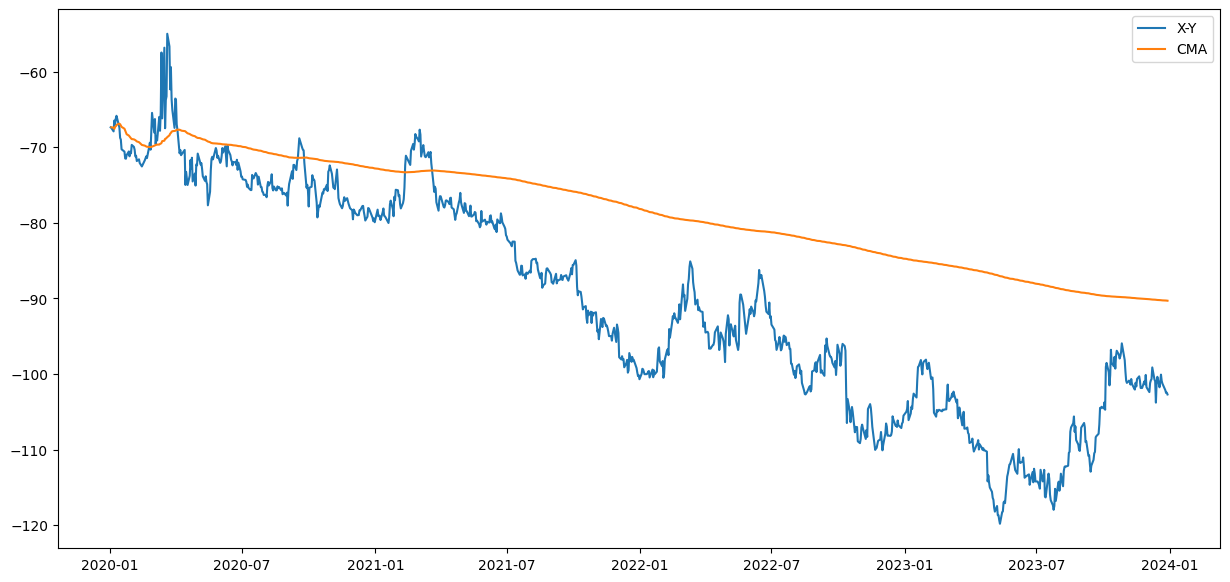

In [17]:
# Mostra a diferença das séries e a média acumulativa da diferença
val = pd.DataFrame(index = X.index, columns=['diff','mu'])
val['diff'] = X - Y
val['mu']= [val['diff'][:i].mean() for i in range(len(val['diff']))]
plt.figure(figsize=(15,7))
plt.plot(val['diff'], label='X-Y')
plt.plot(val['mu'], label='CMA')
plt.legend();

A partir daqui, nossa estratégia de negociação é idêntica àquela utilizada para um único ativo, onde substituímos o ativo pelo spread X-Y. Quando operamos vendido no spread, compramos Y e vendemos X, e vice-versa para posições compradas. Utilizaremos a Média Móvel Cumulativa (CMA) para representar a média, mas você pode facilmente alterá-la para uma Média Móvel (MA) para observar a diferença. No entanto, tenha em mente que o que funciona bem com esses dados pode não ser adequado para outras situações, e cada definição de média pode, em determinados momentos, apresentar um desempenho superior à outra.

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

def backtest_pairs_zscore(symbol1, symbol2, start_date='2020-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    # Baixa os dados de fechamento dos dois símbolos
    df1 = yf.download(symbol1, start=start_date, end=end_date, progress=False).droplevel(level=1, axis=1)['Close']
    df2 = yf.download(symbol2, start=start_date, end=end_date, progress=False).droplevel(level=1, axis=1)['Close']
    
    # Cria um DataFrame único e garante que as datas coincidam
    df = pd.DataFrame({f'Close_{symbol1}': df1, f'Close_{symbol2}': df2})
    df.dropna(inplace=True)
    
    # Calcula os retornos diários de cada ativo
    df[f'r_{symbol1}'] = df[f'Close_{symbol1}'].pct_change()
    df[f'r_{symbol2}'] = df[f'Close_{symbol2}'].pct_change()
    
    # Calcula o spread entre os dois ativos
    df['spread'] = df[f'Close_{symbol1}'] - df[f'Close_{symbol2}']
    
    resultados = []
    
    # Itera sobre diferentes tamanhos de janela para o cálculo rolante
    for janela in range(2, 101):
        # Cálculo da média e desvio padrão rolantes do spread
        rolling_mean = df['spread'].rolling(window=janela).mean()
        rolling_std = df['spread'].rolling(window=janela).std()
        
        # Calcula o zscore do spread
        zscore = (df['spread'] - rolling_mean) / rolling_std
        zscore = zscore.fillna(0)
        df['zscore'] = zscore
        
        # Geração dos sinais:
        # Se zscore > 1: short no ativo 1 e long no ativo 2 (sinal = -1)
        # Se zscore < -1: long no ativo 1 e short no ativo 2 (sinal = 1)
        # Se |zscore| < 0.5: liquida a posição (sinal = 0)
        df['Signal'] = np.nan
        df.loc[df['zscore'] > 1, 'Signal'] = -1
        df.loc[df['zscore'] < -1, 'Signal'] = 1
        df.loc[df['zscore'].abs() < 0.5, 'Signal'] = 0
        # Se não houver sinal definido, mantém o sinal anterior
        df['Signal'] = df['Signal'].ffill().fillna(0)
        
        # Calcula o retorno diário da estratégia
        # Se sinal = 1 => posição: long ativo1, short ativo2 -> retorno = r1 - r2
        # Se sinal = -1 => posição: short ativo1, long ativo2 -> retorno = r2 - r1 (equivalente a - (r1 - r2))
        df['Daily_Return'] = (df[f'r_{symbol1}'] - df[f'r_{symbol2}']) * df['Signal'].shift(1)
        
        # Calcula o retorno acumulado da estratégia para esta janela
        retorno_cumulativo = (df['Daily_Return'] + 1).prod() - 1
        
        resultados.append((janela, retorno_cumulativo * 100))
    
    # Converte os resultados em DataFrame, ordena pelo retorno acumulado e reinicia o índice
    resultados_df = pd.DataFrame(resultados, columns=['Janela (Rolling Window)', 'Lucro/Prejuízo (%)'])
    resultados_df.sort_values(by='Lucro/Prejuízo (%)', ascending=False, inplace=True)
    resultados_df.reset_index(drop=True, inplace=True)
    
    return resultados_df

In [19]:
pd.set_option('display.max_rows', 100)
#pd.reset_option('display.max_rows')

backtest_pairs_zscore('KO', 'PEP')

,Janela (Rolling Window),Lucro/Prejuízo (%)
0,29,57.565118
1,30,43.644529
2,36,42.226775
3,14,42.057120
4,28,41.314104
5,12,39.668031
6,35,38.818353
7,31,38.699828
8,41,37.392034
9,15,37.387743


## Market Screener for Pairs Trading Strategy

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

In [21]:
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2, maxlag=1)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

In [22]:
import yfinance as yf

# S&P 100
symbols = ['AAPL', 'MSFT', 'AMZN', 'META', 'GOOGL', 'GOOG', 'JNJ', 'JPM', 'V', 'PG', 'UNH', 'MA', 'INTC', 'VZ', 'HD', 'T', 'PFE', 'MRK', 'PEP', 'NVS', 'MO', 'KO', 'CMCSA', 'NFLX', 'PM', 'NVDA', 'XOM', 'DIS', 'CSCO', 'ADBE', 'PYPL', 'CVX', 'BAC', 'WFC', 'BA', 'MCD', 'ABT', 'ORCL', 'ACN', 'IBM', 'C', 'MDT', 'UNP', 'MMM', 'BMY', 'HON', 'LIN', 'SAP', 'CRM', 'TXN', 'TMO', 'NKE', 'AVGO', 'QCOM', 'LLY', 'DHR', 'NEE', 'AMGN', 'BUD', 'SBUX', 'GE', 'CAT', 'RTX', 'GS', 'AXP', 'SPG', 'CVS', 'TSLA', 'COST', 'UPS', 'CHTR', 'LMT', 'CI', 'TJX', 'DUK', 'WBA', 'LOW', 'AMT', 'BKNG', 'SYK', 'GILD', 'ISRG', 'BIIB', 'USB', 'PNC', 'MU', 'ZTS', 'BLK', 'PLD', 'CB', 'EOG', 'MMC', 'ATVI', 'INTU', 'ADP', 'CSX', 'BDX', 'ITW', 'VRTX', 'FIS', 'REGN', 'CTSH', 'TFC', 'CCI', 'FDX', 'SQ', 'NOW', 'D']
symbols = symbols[0:30]
data = yf.download(symbols, start='2014-09-01', end='2015-01-01')

# Preços de fechamento
closing_prices = data['Close']
cleaned_data = closing_prices.copy()
cleaned_data = cleaned_data.dropna(axis=1, how='all')
cleaned_data = cleaned_data.dropna(axis=0, how='any')
prices_df = cleaned_data
prices_df.head(2)

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,ADBE,AMZN,CMCSA,CSCO,DIS,GOOG,GOOGL,HD,INTC,...,NVS,PEP,PFE,PG,PM,T,UNH,V,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-02,22.780560,72.099998,17.118999,19.611315,17.506531,81.642082,28.57316,29.210791,70.080620,26.350344,...,56.181053,65.574249,17.019161,60.140011,48.357685,11.648426,71.840309,49.503342,27.376522,60.603786
2014-09-03,21.819063,72.430000,16.950001,19.643532,17.619110,81.767982,28.60335,29.254959,68.427605,26.350344,...,56.480801,66.234810,17.100594,60.082027,48.306786,11.691890,72.172935,49.542545,27.437035,60.985279


Text(0.5, 1.0, 'Assets Correlation Matrix')

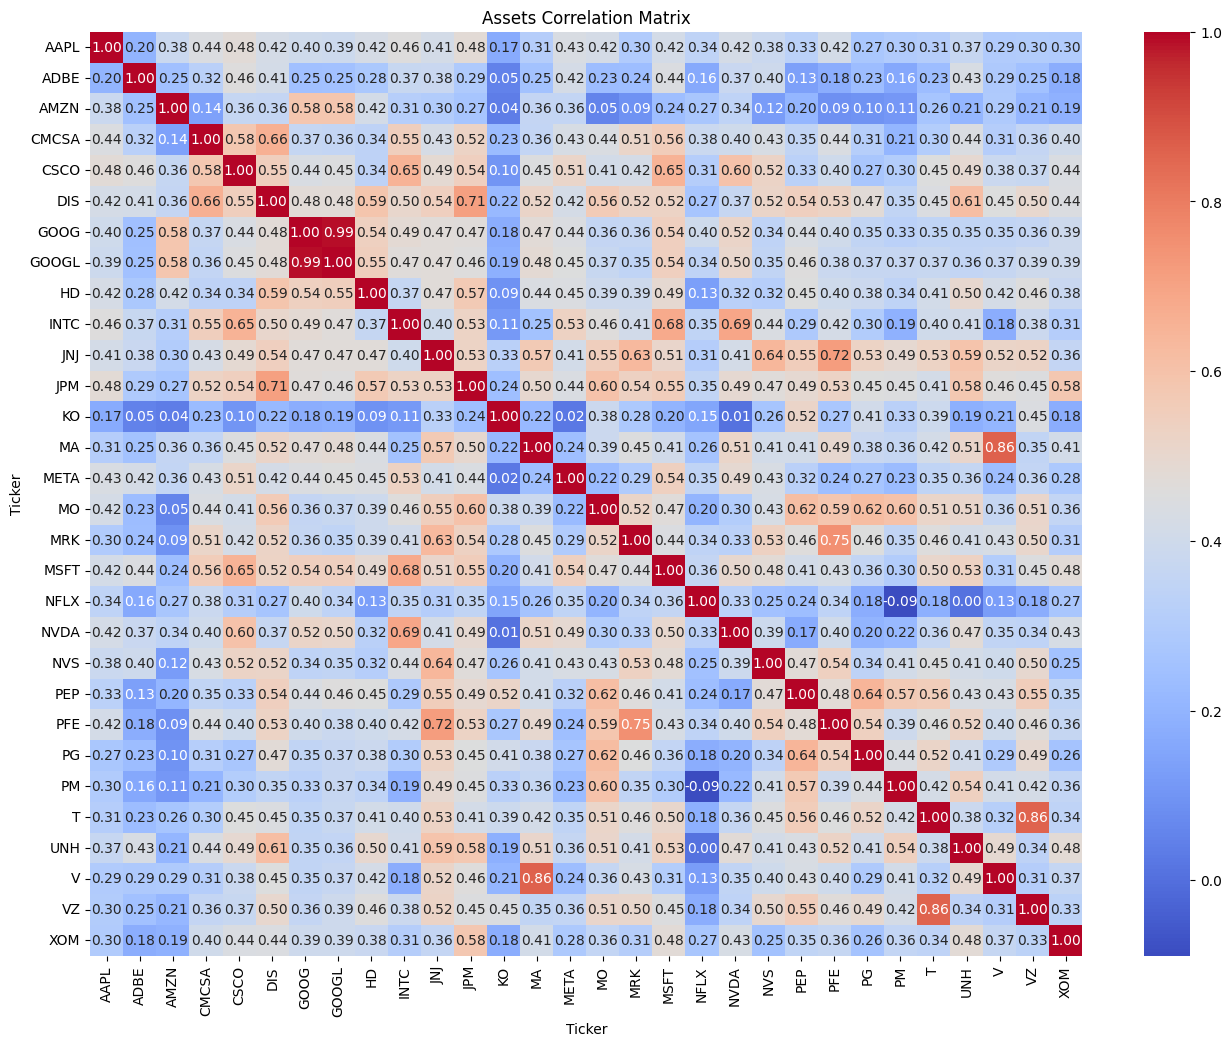

In [23]:
# Pearson correlation formula
fig, ax = plt.subplots(figsize=(16,12))
sns.heatmap(prices_df.pct_change().corr(method ='pearson'), ax=ax, cmap='coolwarm', annot=True, fmt=".2f") #spearman
ax.set_title('Assets Correlation Matrix')

[('AAPL', 'PEP'), ('ADBE', 'DIS'), ('ADBE', 'NVDA'), ('JNJ', 'MSFT'), ('META', 'PM'), ('META', 'T'), ('META', 'VZ'), ('PG', 'UNH'), ('PG', 'V')]


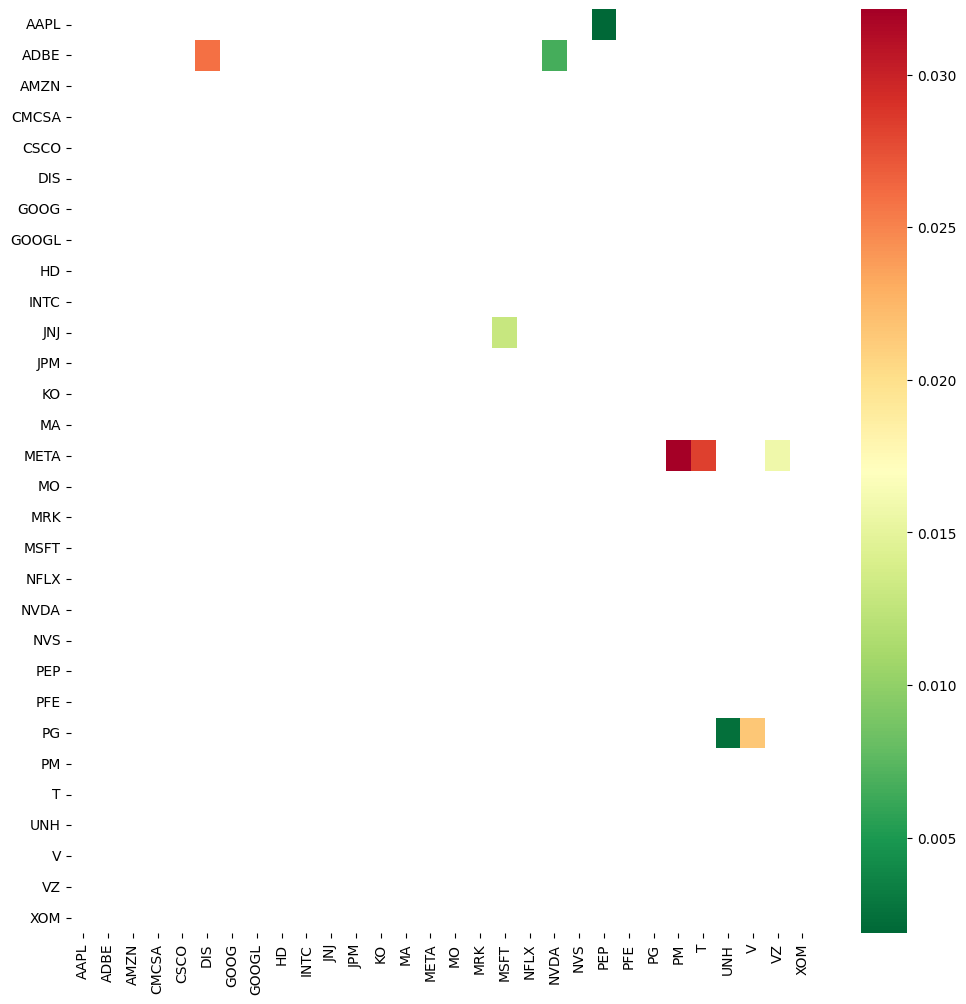

In [24]:
# Heatmap para mostrar p-valores da cointegração entre pares (apenas mostram os valor na diagonal de cima)
scores, pvalues, pairs = find_cointegrated_pairs(prices_df)
import seaborn

plt.figure(figsize=(12, 12)) 

seaborn.heatmap(
    pvalues,
    xticklabels=prices_df.columns,
    yticklabels=prices_df.columns,
    cmap='RdYlGn_r',
    mask = (pvalues >= 0.05))
print(pairs)
plt.show()

In [25]:
S1 = prices_df['DIS']  # The Walt Disney Company (DIS)
S2 = prices_df['INTC']  # Intel Corporation (INTC)

In [26]:
score, pvalue, _ = coint(S1, S2, maxlag=1)
pvalue

0.5191312372889764

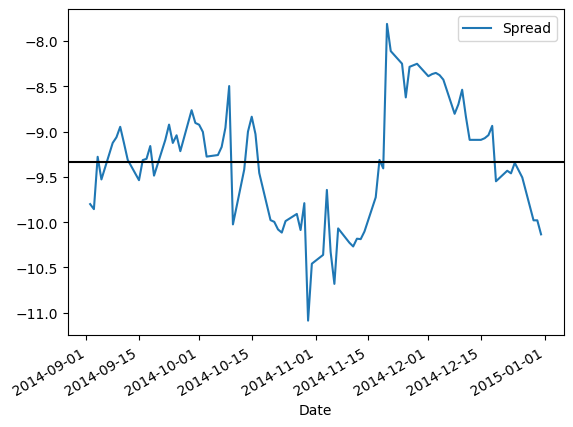

In [27]:
S1 = sm.add_constant(S1)
results = sm.OLS(S2, S1).fit()
S1 = S1['DIS']
b = results.params['DIS']

spread = S2 - b * S1
spread.plot()
plt.axhline(spread.mean(), color='black')
plt.legend(['Spread']);

In [28]:
def zscore(series):
    return (series - series.mean()) / np.std(series)

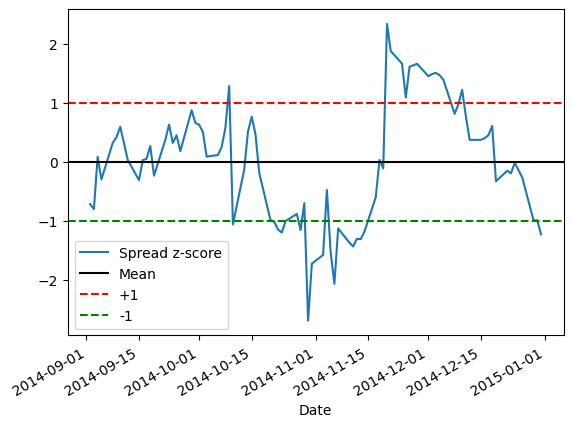

In [29]:
zscore(spread).plot()
plt.axhline(zscore(spread).mean(), color='black')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Spread z-score', 'Mean', '+1', '-1']);

In [30]:
# Cria um DataFrame com sinal e posição por par
trades = pd.concat([zscore(spread), S2 - b * S1], axis=1)
trades.columns = ["signal", "position"]

# Adiciona uma posição long e uma posição short
trades["side"] = 0.0
trades.loc[trades.signal <= -1, "side"] = 1
trades.loc[trades.signal >= 1, "side"] = -1

<AxesSubplot: xlabel='Date'>

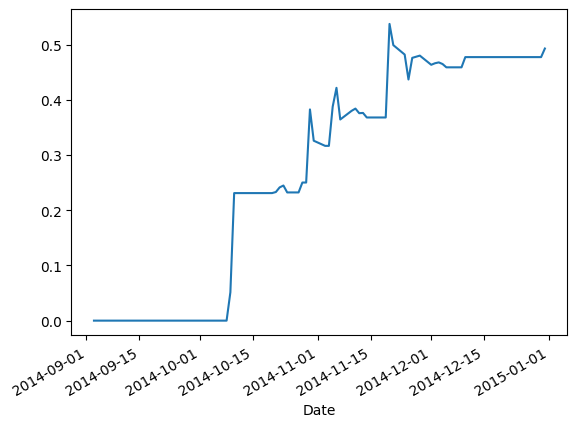

In [31]:
returns = trades.position.pct_change() * trades.side
returns.cumsum().plot()